# Data Cleaning & Chuẩn hóa dữ liệu - Customer Churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('customer_churn.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(df.head())

Shape: (70811, 11)
Columns: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']
   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0       54935  41.0  Female      56               11              9   
1        5772  21.0  Female      35               13              0   
2       28327  44.0    Male       3                4              2   
3       45850  37.0  Female      48               20              8   
4       12775  65.0    Male      40                4              1   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           21.0           Premium       Quarterly        537.0   
1           25.0          Standard          Annual          NaN   
2            NaN             Basic         Monthly          NaN   
3           27.0           Premium       Quarterly          NaN   
4            8.0          Standard      

In [3]:
# Thống kê mô tả biến số
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Total Spend', 'Last Interaction']

desc = df[num_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
desc.columns = ['Số mẫu', 'Giá trị trung bình', 'Độ lệch chuẩn', 
                'Giá trị nhỏ nhất', 'Trung vị', 'Giá trị lớn nhất']
desc['Số mẫu'] = desc['Số mẫu'].astype(int)
desc = desc.round(2)
print(desc.to_string())

                  Số mẫu  Giá trị trung bình  Độ lệch chuẩn  Giá trị nhỏ nhất  Trung vị  Giá trị lớn nhất
Age                65125               41.98          13.93              18.0      42.0              65.0
Tenure             70811               32.01          17.11               1.0      33.0              60.0
Usage Frequency    70811               15.09           8.82               1.0      15.0              30.0
Support Calls      70811                5.40           3.11               0.0       6.0              10.0
Payment Delay      63709               17.14           8.86               0.0      19.0              30.0
Total Spend        63007              540.76         260.70             100.0     534.0            1000.0
Last Interaction   70811               15.50           8.64               1.0      15.0              30.0


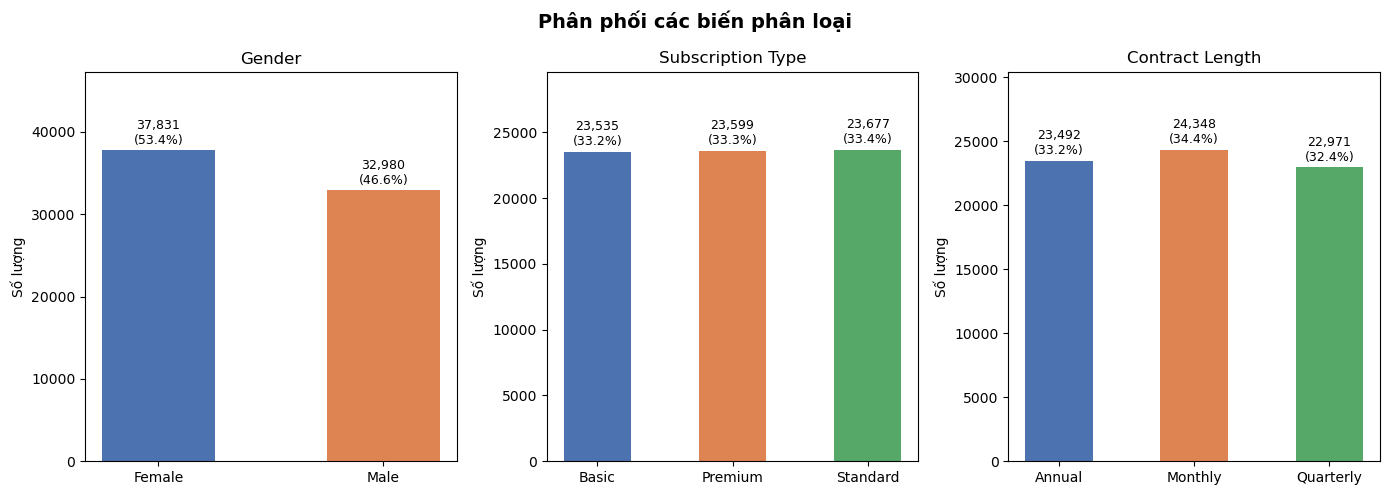

In [4]:
# Phân phối các biến phân loại
import matplotlib.pyplot as plt

df_plot = df.copy()

# Chuẩn hóa tạm để vẽ (không thay đổi df gốc)
df_plot['Gender'] = df_plot['Gender'].str.strip().str.capitalize()
df_plot['Gender'] = df_plot['Gender'].replace({'F': 'Female', 'M': 'Male',
                                               'Female': 'Female', 'Male': 'Male'})

df_plot['Subscription Type'] = df_plot['Subscription Type'].str.strip().str.capitalize()
df_plot['Contract Length'] = df_plot['Contract Length'].str.strip().str.capitalize()

cat_cols = ['Gender', 'Subscription Type', 'Contract Length']
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Phân phối các biến phân loại', fontsize=14, fontweight='bold')

for i, col in enumerate(cat_cols):
    counts = df_plot[col].value_counts().sort_index()
    bars = axes[i].bar(counts.index, counts.values,
                       color=colors[:len(counts)], width=0.5)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Số lượng')
    axes[i].set_ylim(0, counts.max() * 1.25)
    for bar, v in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 300,
                     f'{v:,}\n({v/len(df_plot)*100:.1f}%)',
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

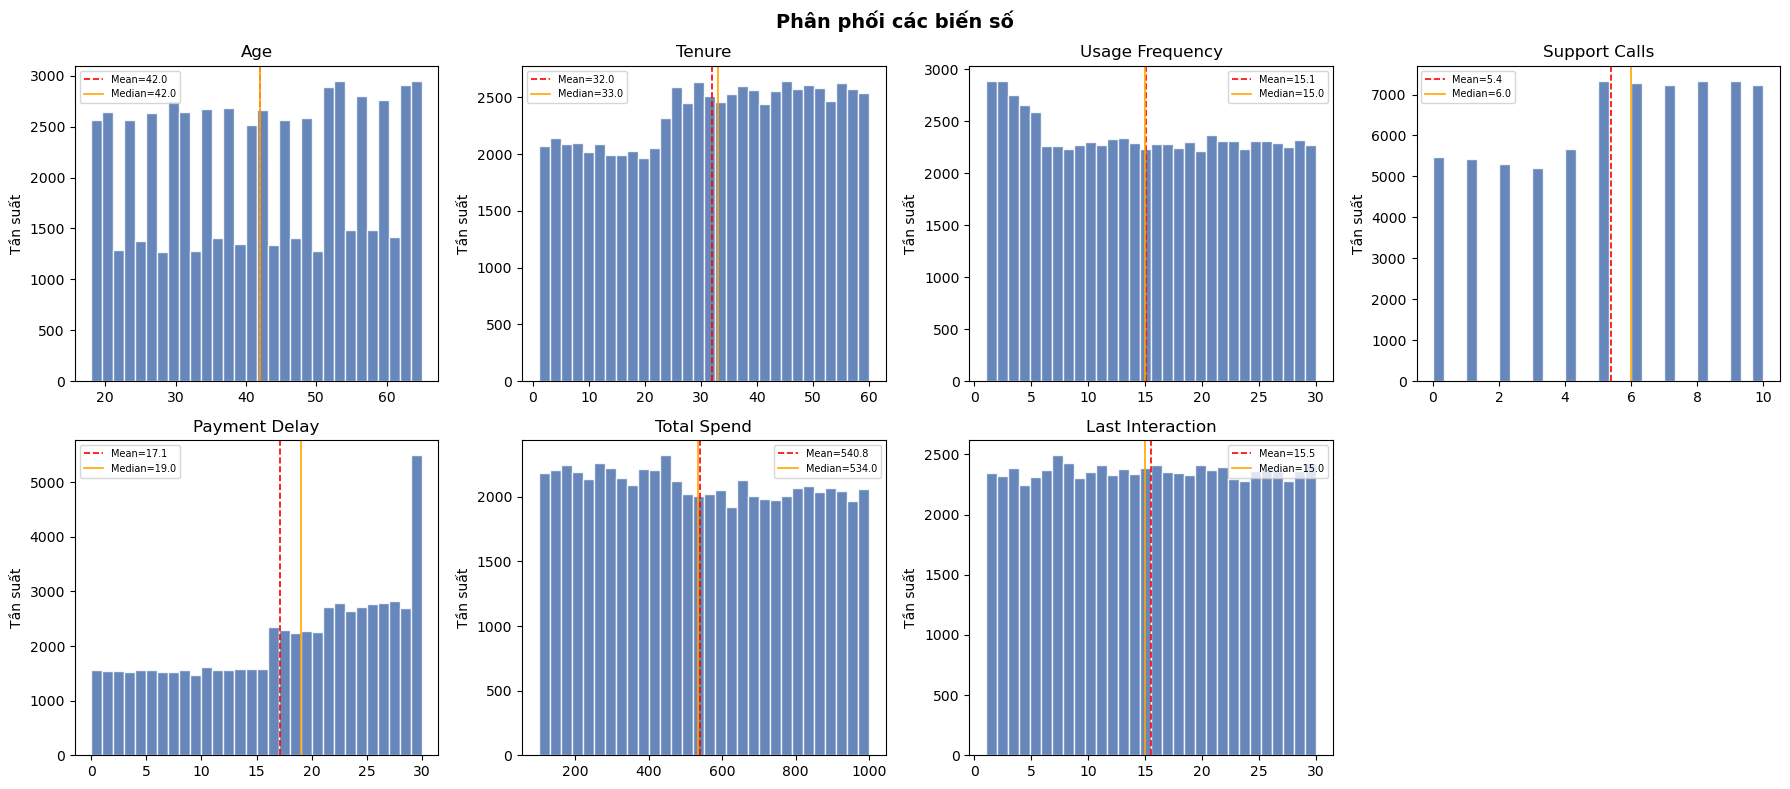

In [5]:
# Phân phối các biến số
num_cols = ['Age', 'Tenure', 'Usage Frequency',
            'Support Calls', 'Payment Delay',
            'Total Spend', 'Last Interaction']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
fig.suptitle('Phân phối các biến số', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#4C72B0', 
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_ylabel('Tần suất')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', 
                    linewidth=1.2, label=f'Mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-', 
                    linewidth=1.2, label=f'Median={df[col].median():.1f}')
    axes[i].legend(fontsize=7)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

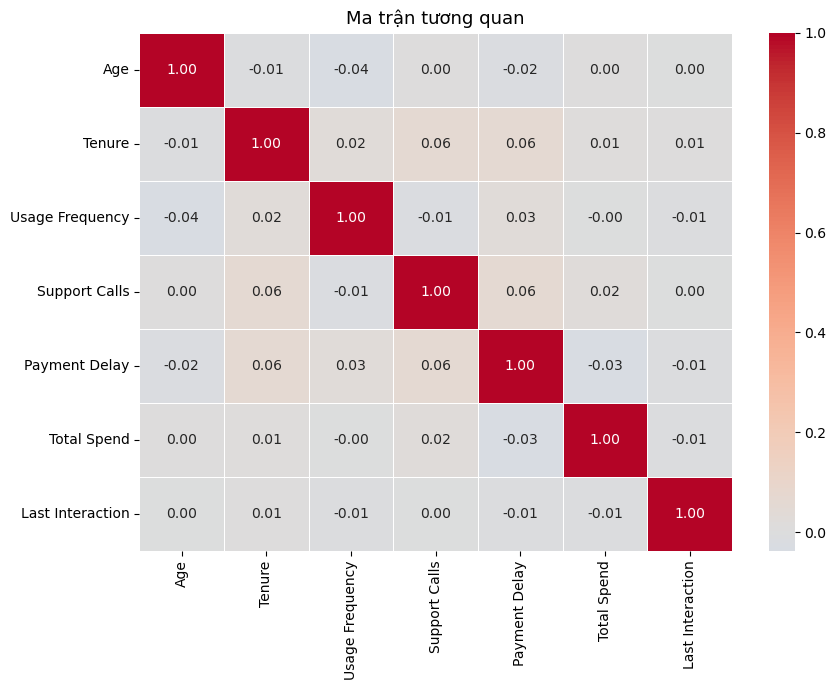

In [6]:
# Tương quan giữa các biến số 
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Total Spend', 'Last Interaction']

fig, ax = plt.subplots(figsize=(9, 7))

corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Ma trận tương quan', fontsize=13)

plt.tight_layout()
plt.show()

In [7]:
# KIỂM TRA 1: Giá trị thiếu 
print('='*45)
print('1. KIỂM TRA GIÁ TRỊ THIẾU')
print('='*45)
null_df = pd.DataFrame({
    'Số NULL': df.isnull().sum(),
    'Tỷ lệ (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_df[null_df['Số NULL'] > 0])

1. KIỂM TRA GIÁ TRỊ THIẾU
               Số NULL  Tỷ lệ (%)
Age               5686       8.03
Payment Delay     7102      10.03
Total Spend       7804      11.02


In [8]:
# KIỂM TRA 2: Trùng lặp
print('='*45)
print('2. KIỂM TRA TRÙNG LẶP')
print('='*45)
print(f'Số hàng trùng hoàn toàn : {df.duplicated().sum():,}')
print(f'CustomerID trùng        : {df["CustomerID"].duplicated().sum():,}')

2. KIỂM TRA TRÙNG LẶP
Số hàng trùng hoàn toàn : 3,643
CustomerID trùng        : 6,437


In [9]:
# KIỂM TRA 3: Sai định dạng 
print('='*45)
print('3. KIỂM TRA SAI ĐỊNH DẠNG')
print('='*45)
for col in ['Gender', 'Subscription Type', 'Contract Length']:
    print(f'\n{col}:')
    print(df[col].value_counts(dropna=False).to_string())

3. KIỂM TRA SAI ĐỊNH DẠNG

Gender:
Gender
Female    33505
Male      29323
F          1483
female     1450
FEMALE     1393
male       1226
M          1223
MALE       1208

Subscription Type:
Subscription Type
Standard    21727
Premium     21714
Basic       21672
STANDARD      977
standard      973
PREMIUM       948
basic         941
premium       937
BASIC         922

Contract Length:
Contract Length
Monthly      22454
Annual       21672
Quarterly    21101
monthly        968
QUARTERLY      941
quarterly      929
ANNUAL         926
MONTHLY        926
annual         894


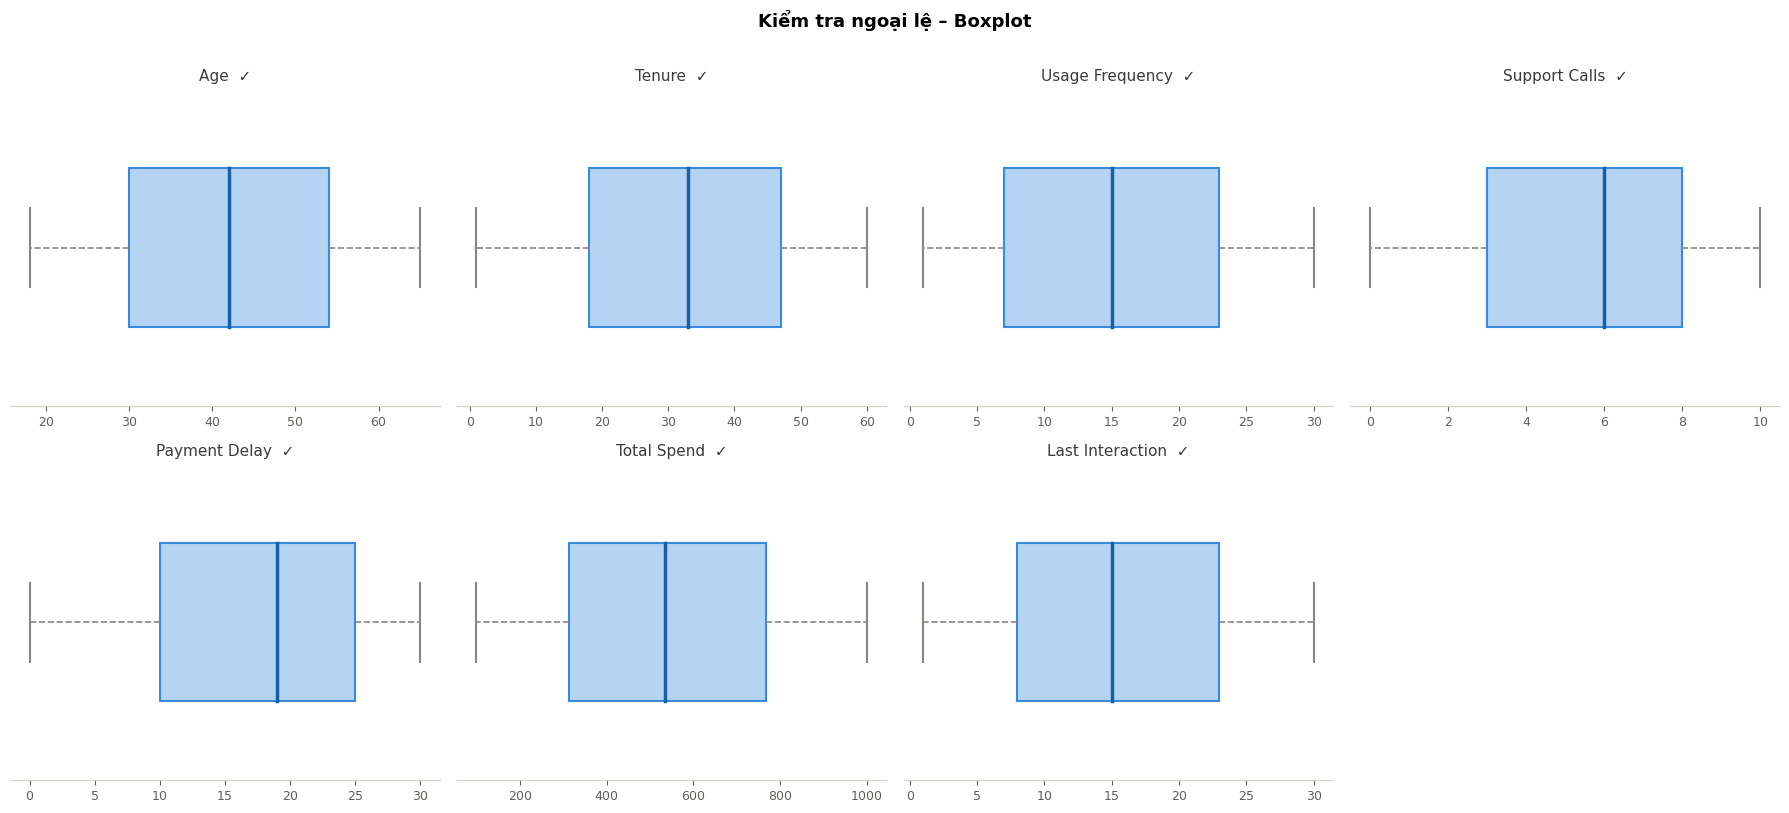

In [10]:
#  KIỂM TRA 4: Ngoại lệ (Boxplot) 
outlier_cols = ['Age', 'Tenure', 'Usage Frequency',
                'Support Calls', 'Payment Delay',
                'Total Spend', 'Last Interaction']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    ax = axes[i]
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    ax.boxplot(df[col].dropna(), vert=False, patch_artist=True, widths=0.5,
               flierprops=dict(marker='o', markerfacecolor='#E24B4A',
                               markeredgecolor='#E24B4A', markersize=5, alpha=0.7),
               medianprops=dict(color='#185FA5', linewidth=2.5),
               boxprops=dict(facecolor='#B5D4F4', color='#378ADD', linewidth=1.5),
               whiskerprops=dict(color='#888780', linewidth=1.2, linestyle='--'),
               capprops=dict(color='#888780', linewidth=1.5))

    title_color = '#E24B4A' if n_out > 0 else '#3B3B3B'
    ax.set_title(f'{col}  ({n_out} ngoại lệ)' if n_out > 0 else f'{col}  ✓',
                 fontsize=11, color=title_color, pad=6)
    ax.set_yticks([])
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color('#D3D1C7')
    ax.tick_params(axis='x', labelsize=9, colors='#5F5E5A')
    ax.set_facecolor('white')

axes[-1].set_visible(False)
fig.suptitle('Kiểm tra ngoại lệ – Boxplot', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
#  XỬ LÝ 1: Chuẩn hóa định dạng trước 
df['Gender'] = df['Gender'].str.strip().str.capitalize()
# Female/FEMALE/F/female → Female | Male/MALE/M/male → Male
df['Gender'] = df['Gender'].replace({'F': 'Female', 'M': 'Male'})

df['Subscription Type'] = df['Subscription Type'].str.strip().str.capitalize()
df['Contract Length']   = df['Contract Length'].str.strip().str.capitalize()

print('Sau khi chuẩn hóa định dạng:')
for col in ['Gender', 'Subscription Type', 'Contract Length']:
    print(f'\n{col}: {df[col].value_counts().to_dict()}')

Sau khi chuẩn hóa định dạng:

Gender: {'Female': 37831, 'Male': 32980}

Subscription Type: {'Standard': 23677, 'Premium': 23599, 'Basic': 23535}

Contract Length: {'Monthly': 24348, 'Annual': 23492, 'Quarterly': 22971}


In [12]:
# XỬ LÝ 2: Trùng lặp
df = df.drop_duplicates()
df = df.drop_duplicates(subset=['CustomerID'], keep='first')
df = df.reset_index(drop=True)
print(f'Shape sau xử lý trùng lặp: {df.shape}')

Shape sau xử lý trùng lặp: (64374, 11)


In [13]:
#  XỬ LÝ 3: Giá trị thiếu 
# Điền median cho cột số 
for col in ['Age', 'Payment Delay', 'Total Spend']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'[{col}] điền median = {median_val:.1f}')

print(f'\nNULL còn lại: {df.isnull().sum().sum()}')

[Age] điền median = 42.0
[Payment Delay] điền median = 19.0
[Total Spend] điền median = 534.0

NULL còn lại: 0


In [14]:
#  XỬ LÝ 4: Ngoại lệ (IQR clip) 
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f'[{col}] {n_out} ngoại lệ → clip [{lower:.1f}, {upper:.1f}]')
    else:
        print(f'[{col}] không có ngoại lệ ')

[Age] không có ngoại lệ 
[Tenure] không có ngoại lệ 
[Usage Frequency] không có ngoại lệ 
[Support Calls] không có ngoại lệ 
[Payment Delay] không có ngoại lệ 
[Total Spend] không có ngoại lệ 
[Last Interaction] không có ngoại lệ 


In [15]:
#Feature Engineering
df['spend_per_tenure'] = df['Total Spend'] / (df['Tenure'] + 1)
df['support_rate']     = df['Support Calls'] / (df['Tenure'] + 1)
df['payment_risk']     = (df['Payment Delay'] > df['Payment Delay'].median()).astype(int)
df['high_usage']       = (df['Usage Frequency'] > df['Usage Frequency'].median()).astype(int)
df['recency_risk']     = (df['Last Interaction'] > 20).astype(int)
print(f'Shape sau Feature Engineering: {df.shape}')

Shape sau Feature Engineering: (64374, 16)


In [16]:
# Loại cột không liên quan 
df = df.drop(columns=['CustomerID'])
print(f'Đã bỏ CustomerID')
print(f'Shape: {df.shape}')

Đã bỏ CustomerID
Shape: (64374, 15)


In [17]:
#  Xuất file 
df.to_csv('data_cleaned.csv', index=False)
print(f'Đã xuất data_cleaned.csv')
print(f'   Shape: {df.shape}')
print(f'   Columns: {df.columns.tolist()}')


Đã xuất data_cleaned.csv
   Shape: (64374, 15)
   Columns: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'spend_per_tenure', 'support_rate', 'payment_risk', 'high_usage', 'recency_risk']
